In [1]:
from ase.build import bulk

si = bulk('Si', 'diamond', 5.48)

In [2]:
from gpaw import GPAW, PW, FermiDirac

calc = GPAW(mode=PW(400),
            xc='PBE',
            kpts=(15, 15, 15),
            random=True,
            occupations=FermiDirac(0.01),
            txt='Si_gs.txt')
si.set_calculator(calc)
si.get_potential_energy()
calc.write('Si_gs.gpw')

In [3]:
from gpawdev import band_gap

bandgap = band_gap(calc)
e=calc.get_potential_energy()
ef = calc.get_fermi_level()

print(f'E = {e:.4f} eV, Ef = {ef:.3f} eV')

Band gap: 0.6251 eV
E = -10.7988 eV, Ef = 5.498 eV


In [4]:
nbands = 8
calc = GPAW('Si_gs.gpw',
            fixdensity=True,
            nbands=24,
            symmetry='off')

In [5]:
cell=calc.atoms.get_cell(complete=True)
bp=cell.bandpath('WLGXWK',npoints=480)
kpts=bp.kpts
(x, X, labels) = bp.get_linear_kpoint_axis()

print('kpts:')
print(kpts)
print('x:')
print(x)
print('X:')
print(X)
print('labels:')
print(labels)

kpts:
[[0.5        0.25       0.75      ]
 [0.5        0.25255102 0.74744898]
 [0.5        0.25510204 0.74489796]
 ...
 [0.38       0.37       0.75      ]
 [0.3775     0.3725     0.75      ]
 [0.375      0.375      0.75      ]]
x:
[0.         0.00827291 0.01654582 0.02481873 0.03309164 0.04136454
 0.04963745 0.05791036 0.06618327 0.07445618 0.08272909 0.091002
 0.09927491 0.10754781 0.11582072 0.12409363 0.13236654 0.14063945
 0.14891236 0.15718527 0.16545818 0.17373108 0.18200399 0.1902769
 0.19854981 0.20682272 0.21509563 0.22336854 0.23164145 0.23991435
 0.24818726 0.25646017 0.26473308 0.27300599 0.2812789  0.28955181
 0.29782472 0.30609763 0.31437053 0.32264344 0.33091635 0.33918926
 0.34746217 0.35573508 0.36400799 0.3722809  0.3805538  0.38882671
 0.39709962 0.40537253 0.41364544 0.42191835 0.43019126 0.43846417
 0.44673707 0.45500998 0.46328289 0.4715558  0.47982871 0.48810162
 0.49637453 0.50464744 0.51292035 0.52119325 0.52946616 0.53773907
 0.54601198 0.55428489 0.5625578  0

In [6]:
def pretty(kpt):
    if kpt == 'G':
        kpt = r'$\Gamma$'
    elif len(kpt) == 2:
        kpt = kpt[0] + '$_' + kpt[1] + '$'
    return kpt

xticklabels=[pretty(kp) for kp in labels]
xticklabels

['W', 'L', '$\\Gamma$', 'X', 'W', 'K']

In [7]:
import numpy as np

calc.set(kpts=kpts)
calc.get_potential_energy()
e_kn = np.array([calc.get_eigenvalues(k) for k in range(len(kpts))])

print('e_kn:')
print(e_kn)

e_kn:
[[-2.52646667 -2.52646277  1.31284621 ... 28.49221616 32.37883021
  32.45526418]
 [-2.55906834 -2.49397213  1.28898766 ... 28.55278846 32.4069
  32.74365482]
 [-2.59175675 -2.46161794  1.26594263 ... 28.61549547 32.32673061
  32.59077713]
 ...
 [-3.09250745 -2.09901297  0.87660675 ... 27.83204372 30.0770388
  30.79610962]
 [-3.09319123 -2.09871869  0.87606386 ... 27.83515044 30.0771394
  30.79912641]
 [-3.09341916 -2.09862073  0.87588289 ... 27.83618049 30.07068541
  30.79333614]]


In [8]:
e_kn -= ef
emin = e_kn.min() - 1.0
emax = e_kn[:, nbands].max() + 1.0

print(f'Emin = {emin:.4f} eV, Emax = {emax:.4f} eV')

Emin = -13.2240 eV, Emax = 12.0878 eV


Text(0.5, 1.0, 'Bulk Si bandstructure')

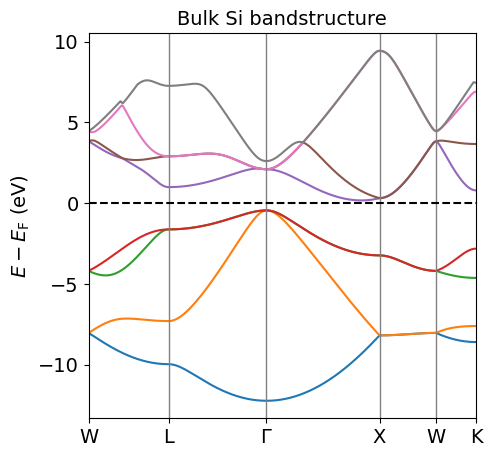

In [9]:
import matplotlib.pyplot as plt

fs = 14
fig, ax = plt.subplots(figsize=(5.0, 5.0))

for n in range(nbands):
    ax.plot(x, e_kn[:, n])

for p in X[1:-1]:
    ax.axvline(p, color='gray', linewidth=1.0)
ax.axhline(0, color='k', linestyle='--')
ax.set_xlim(0, x[-1])
ax.set_xticks(X)
ax.set_xticklabels(xticklabels, fontsize=fs)
plt.yticks(fontsize=fs)
ax.set_ylabel(r'$E -E_{\mathrm{F}}$ (eV)', fontsize=fs)
ax.set_title('Bulk Si bandstructure', fontsize=fs)